# 01 Data Audit

## 목표
- 원본 1분봉 데이터 품질을 점검한다.
- 시간축 연속성과 gap 분포를 확인한다.
- 이상 이벤트 후보 시점을 추출한다.
- 기존 feature/label pickle의 재사용 가능성을 검토한다.

## 이 노트북의 산출물
- `raw_summary.csv`
- `gap_summary.csv`
- `event_candidates.csv`
- `feature_summary.csv`


In [7]:
import os
from pathlib import Path
import warnings

# 프로젝트와 데이터 위치를 먼저 고정해두면
# 이후 셀에서 경로를 반복해서 적지 않아도 되고, 경로 오타도 줄일 수 있다.
PROJECT_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects")
DATA_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data")
OUTPUT_DIR = PROJECT_DIR / "outputs" / "01_data_audit"

# matplotlib은 캐시 디렉토리가 쓰기 가능하지 않으면 경고가 자주 발생한다.
# 그래서 프로젝트 내부에 임시 설정 폴더를 따로 만들어 시각화 환경을 안정화한다.
MPLCONFIG_DIR = PROJECT_DIR / ".mplconfig"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

# audit 단계에서는 경고보다 데이터 구조 파악이 중요하므로 일반 경고는 잠시 숨긴다.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 출력 표가 잘리지 않도록 표시 옵션을 완화한다.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")

RAW_PATH = DATA_DIR / "sub_upbit_eth_min_tick.csv"
FEAT_PATH = DATA_DIR / "sub_upbit_eth_min_feature_labels.pkl"

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"RAW_PATH exists: {RAW_PATH.exists()}")
print(f"FEAT_PATH exists: {FEAT_PATH.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


PROJECT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects
RAW_PATH exists: True
FEAT_PATH exists: True
OUTPUT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects/outputs/01_data_audit


### 결과 해석
- 프로젝트 폴더, 원본 CSV, feature pickle 경로가 모두 잡히면 이후 분석은 같은 기준 경로에서 재현할 수 있습니다. 출력 폴더도 자동 생성되므로 결과물이 흩어지지 않습니다.
- 문제는 `matplotlib` 캐시 경고가 자주 나는 환경이라는 점인데, 원인은 기본 캐시 경로가 쓰기 불가능하기 때문입니다. `MPLCONFIGDIR`를 프로젝트 내부로 지정해 시각화 셀 실행 안정성을 높였습니다.


## 1. Raw Tick Data 파악

`sub_upbit_eth_min_tick.csv` 기준으로 시간축, 기본 통계, gap, 초기 파생변수를 점검합니다.


In [8]:
# 1분봉 분석에서는 시간 순서가 깨지면 모든 rolling 계산이 왜곡된다.
# 따라서 로드 직후 시간 정렬을 먼저 수행한다.
raw = pd.read_csv(RAW_PATH, parse_dates=["time"]).sort_values("time").reset_index(drop=True)

# 파생변수 추가
# ret_1: 가격 수준이 아닌 변화율로 비교하기 위한 가장 기본적인 수익률이다.
raw["ret_1"] = raw["close"].pct_change()

# log_ret_1: 로그수익률은 여러 구간을 더하기 쉬워서 변동성 계산에 자주 사용된다.
raw["log_ret_1"] = np.log(raw["close"]).diff()

# hl_range_pct: 한 분 안에서 가격이 얼마나 크게 흔들렸는지를 보는 분봉 내 변동폭이다.
raw["hl_range_pct"] = (raw["high"] - raw["low"]) / raw["close"]

# body_pct: 시가와 종가 차이의 절대값으로, 캔들의 실질적인 방향성 크기를 본다.
raw["body_pct"] = (raw["close"] - raw["open"]).abs() / raw["open"]

# rv_30: 최근 30분 로그수익률의 표준편차에 sqrt(30)을 곱한 실현 변동성이다.
# 단기적으로 시장이 얼마나 불안정해졌는지 포착하기 위해 추가한다.
raw["rv_30"] = raw["log_ret_1"].rolling(30).std() * np.sqrt(30)

# vol_z_60: 현재 거래량이 최근 60분 평균 대비 몇 표준편차 떨어져 있는지 보여주는 값이다.
# 절대 거래량보다 '평소 대비 급증했는가'를 보기 위해 z-score 형태로 만든다.
raw["vol_z_60"] = (
    (raw["volume"] - raw["volume"].rolling(60).mean())
    / raw["volume"].rolling(60).std()
)

# 시간 축 파악
# gaps: 직전 관측치와 현재 관측치 사이가 몇 분 비어 있는지를 뜻한다.
gaps = raw["time"].diff().dt.total_seconds().div(60)

# expected_minutes: 시작~끝 구간을 이상적으로 1분 단위로 꽉 채웠을 때의 시간축이다.
expected_minutes = pd.date_range(raw["time"].min(), raw["time"].max(), freq="min")

# missing_minutes: 실제 데이터에 존재하지 않는 분을 찾아 gap 규모를 직접 세기 위한 값이다.
missing_minutes = expected_minutes.difference(pd.DatetimeIndex(raw["time"]))

# 품질 점검 요약표
raw_summary = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "start_time",
            "end_time",
            "duplicate_time_count",
            "expected_minute_count",
            "observed_minute_count",
            "missing_minute_count",
            "missing_minute_ratio",
            "pct_gap_gt_1min",
            "max_gap_min",
        ],
        "value": [
            len(raw),
            raw.shape[1],
            raw["time"].min(),
            raw["time"].max(),
            int(raw["time"].duplicated().sum()),
            len(expected_minutes),
            raw["time"].nunique(),
            len(missing_minutes),
            len(missing_minutes) / len(expected_minutes),
            float((gaps > 1).mean()),
            float(gaps.max()),
        ],
    }
)

# gap 분포를 따로 저장해두면 이후 전처리 규칙을 세울 때 바로 재사용할 수 있다.
gap_summary = (
    gaps.value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .reset_index()
    .rename(columns={"time": "gap_min"})
)

raw_summary.to_csv(OUTPUT_DIR / "raw_summary.csv", index=False)
gap_summary.to_csv(OUTPUT_DIR / "gap_summary.csv", index=False)

display(raw_summary)
display(gap_summary.head(15))
display(raw.head())
display(raw.tail())


,metric,value
0,row_count,1000000
1,column_count,12
2,start_time,2017-09-25 03:00:00
3,end_time,2019-11-03 10:33:00
4,duplicate_time_count,0
5,expected_minute_count,1107814
6,observed_minute_count,1000000
7,missing_minute_count,107814
8,missing_minute_ratio,0.097321
9,pct_gap_gt_1min,0.055867


,gap_min,count
0,1.000000,944132
1,2.000000,33776
2,3.000000,14829
3,4.000000,2158
4,5.000000,898
5,6.000000,2942
6,7.000000,822
7,8.000000,169
8,9.000000,116
9,10.000000,41


,time,open,high,low,close,volume,ret_1,log_ret_1,hl_range_pct,body_pct,rv_30,vol_z_60
0,2017-09-25 03:00:00,324500,325500,322000,324000,52.477251,NaN,NaN,0.010802,0.001541,NaN,NaN
1,2017-09-25 03:01:00,324000,324000,322500,324000,39.061889,0.000000,0.000000,0.004630,0.000000,NaN,NaN
2,2017-09-25 03:02:00,322500,324500,322500,324500,12.794000,0.001543,0.001542,0.006163,0.006202,NaN,NaN
3,2017-09-25 03:05:00,324000,324000,323000,324000,33.365246,-0.001541,-0.001542,0.003086,0.000000,NaN,NaN
4,2017-09-25 03:06:00,324000,325000,322500,324000,46.224544,0.000000,0.000000,0.007716,0.000000,NaN,NaN


,time,open,high,low,close,volume,ret_1,log_ret_1,hl_range_pct,body_pct,rv_30,vol_z_60
999995,2019-11-03 10:29:00,212650,212800,212600,212800,30.996276,0.000000,0.000000,0.000940,0.000705,0.005068,-0.111002
999996,2019-11-03 10:30:00,212800,212800,212600,212600,3.224132,-0.000940,-0.000940,0.000941,0.000940,0.005134,-0.497866
999997,2019-11-03 10:31:00,212600,212600,212400,212400,135.351681,-0.000941,-0.000941,0.000942,0.000941,0.005118,1.297567
999998,2019-11-03 10:32:00,212400,212500,212150,212500,329.331920,0.000471,0.000471,0.001647,0.000471,0.005132,3.471653
999999,2019-11-03 10:33:00,212400,212500,212200,212350,141.525940,-0.000706,-0.000706,0.001413,0.000235,0.005159,1.128413


### 결과 해석
- 원본 데이터는 **1,000,000행**, 기간은 **2017-09-25 ~ 2019-11-03**, 중복 시각은 **0건**으로 기본 구조는 양호합니다. 다만 전체 1분 시간축 기준으로 **107,814분(9.73%)**이 비어 있고, **1분 초과 gap 비율이 5.59%**, 최대 gap은 **4,924분**이라 완전한 연속 시계열로 보면 안 됩니다.
- 문제는 gap이 적지 않아 rolling feature나 이상치 탐지가 왜곡될 수 있다는 점입니다. 원인은 거래 공백, 저유동성, 다운로드 구간 누락 가능성이며, 해결방안은 `gap 태그 생성`, `긴 공백 전후 구간 제외`, `세그먼트별 분석`입니다. 인사이트는 이 프로젝트가 예측보다 `이상 상태 모니터링`과 `변화 감지`에 더 잘 맞는다는 점입니다.


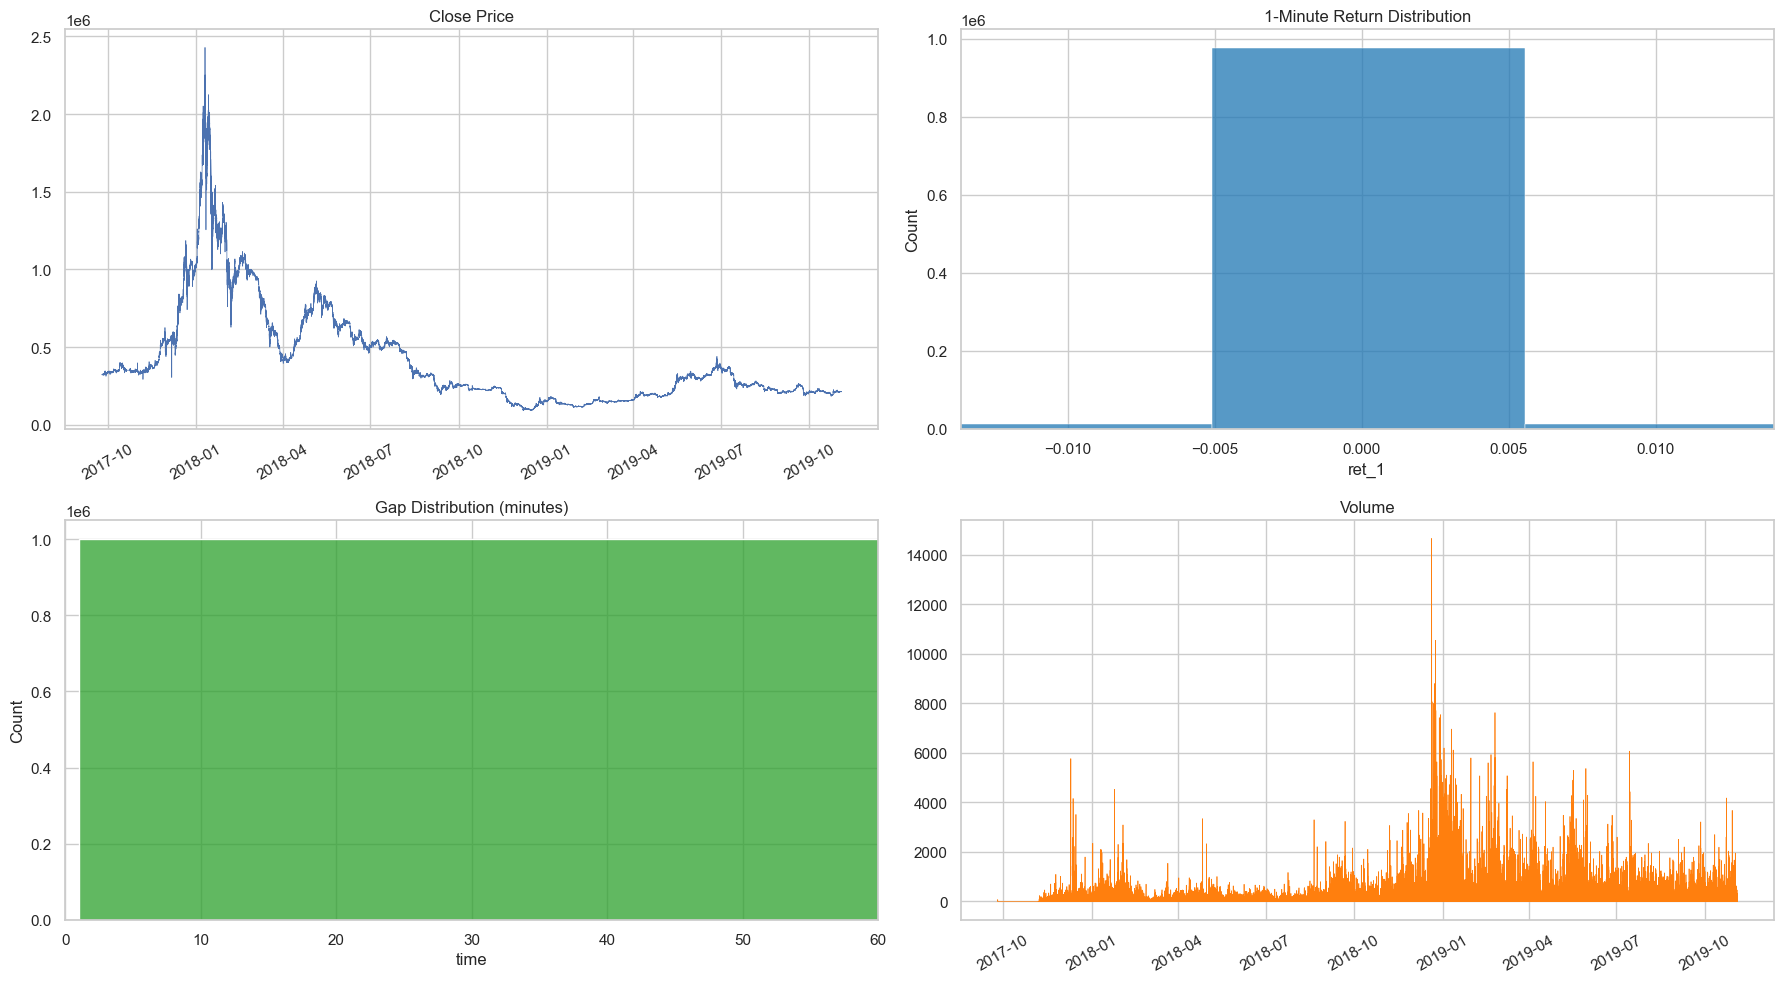

In [9]:
# 분포와 시계열 모양을 함께 보면 숫자 요약표에서 놓친 레짐 전환과 극단값을 빨리 파악할 수 있다.
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 종가 시계열: 장기 추세와 급격한 상태 변화를 한눈에 본다.
axes[0, 0].plot(raw["time"], raw["close"], linewidth=0.5)
axes[0, 0].set_title("Close Price")
axes[0, 0].tick_params(axis="x", rotation=30)

# 수익률 히스토그램: 꼬리가 두꺼운지, 즉 극단 변동이 잦은지 확인한다.
# x축은 0.1%~99.9% 분위수로 잘라 극단값 때문에 중앙 구조가 묻히지 않게 한다.
sns.histplot(raw["ret_1"].dropna(), bins=120, ax=axes[0, 1], color="tab:blue")
axes[0, 1].set_title("1-Minute Return Distribution")
axes[0, 1].set_xlim(raw["ret_1"].quantile(0.001), raw["ret_1"].quantile(0.999))

# gap 히스토그램: 데이터 품질 문제를 시각적으로 확인한다.
# 60분까지만 확대하면 대부분의 실제 gap 구조를 보기 쉽다.
sns.histplot(gaps.dropna(), bins=40, ax=axes[1, 0], color="tab:green")
axes[1, 0].set_title("Gap Distribution (minutes)")
axes[1, 0].set_xlim(0, min(60, gaps.max()))

# 거래량 시계열: burst 구간과 지나치게 조용한 구간이 함께 있는지 본다.
axes[1, 1].plot(raw["time"], raw["volume"], linewidth=0.5, color="tab:orange")
axes[1, 1].set_title("Volume")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### 결과 해석
- 시각화에서는 가격의 장기 레짐 변화, 수익률 분포의 두꺼운 꼬리, 거래량 burst가 동시에 보입니다. 즉 평온한 구간과 급격한 상태 변화가 공존하는 전형적인 고빈도 금융 시계열입니다.
- 문제는 극단값이 일부 구간에 몰려 있어 평균 중심 모델이 왜곡될 수 있다는 점입니다. 원인은 저유동성 시기와 시장 급변 구간이 섞여 있기 때문이며, 해결방안은 `강건한 스케일링`, `초기 저유동성 구간 분리`, `이벤트 기반 평가`입니다. 인사이트는 단순 회귀보다 이상치 중심 접근이 더 자연스럽다는 점입니다.


In [10]:
# 어떤 시점을 '이상 이벤트 후보'로 볼지 빠르게 정리하기 위한 컬럼 목록이다.
# 이후 사람이 직접 확인할 때 가격, 거래량, 변동성 정보를 한 번에 보도록 최소 컬럼만 남긴다.
event_columns = [
    "time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "ret_1",
    "hl_range_pct",
    "rv_30",
    "vol_z_60",
]

# 서로 다른 관점의 이상 이벤트를 섞어 후보군을 만든다.
# 1) 급등 2) 급락 3) 절대 거래량 급증 4) 평소 대비 거래량 급증 5) 변동성 급등
event_candidates = pd.concat(
    [
        raw.nlargest(15, "ret_1")[event_columns].assign(event_type="top_positive_return"),
        raw.nsmallest(15, "ret_1")[event_columns].assign(event_type="top_negative_return"),
        raw.nlargest(15, "volume")[event_columns].assign(event_type="top_volume"),
        raw.nlargest(15, "vol_z_60")[event_columns].assign(event_type="top_volume_zscore"),
        raw.nlargest(15, "rv_30")[event_columns].assign(event_type="top_realized_volatility"),
    ],
    ignore_index=True,
)

# 정렬 후 저장해두면 이후 EDA나 수동 라벨 검토 때 바로 사용할 수 있다.
event_candidates = event_candidates.sort_values(["event_type", "time"]).reset_index(drop=True)
event_candidates.to_csv(OUTPUT_DIR / "event_candidates.csv", index=False)

display(event_candidates.head(30))
print("Saved:", OUTPUT_DIR / "event_candidates.csv")


,time,open,high,low,close,volume,ret_1,hl_range_pct,rv_30,vol_z_60,event_type
0,2017-10-31 23:09:00,398500,398500,347500,347500,0.010000,-0.127980,0.146763,0.197075,NaN,top_negative_return
1,2017-11-06 15:43:00,292500,292500,292500,292500,0.010000,-0.154991,0.000000,0.169567,-0.270190,top_negative_return
2,2017-11-12 07:10:00,358100,358100,340050,340800,106.514660,-0.048311,0.052964,0.080694,1.663658,top_negative_return
3,2017-11-12 07:14:00,342150,342150,342150,342150,13.099117,-0.047334,0.000000,0.103427,-0.731645,top_negative_return
4,2017-11-12 07:16:00,359200,359200,342300,342400,39.564843,-0.046771,0.049357,0.122558,-0.098266,top_negative_return
5,2017-11-13 01:06:00,395100,395100,373000,373100,63.772432,-0.055682,0.059233,0.072299,0.000060,top_negative_return
6,2017-12-06 13:59:00,556600,556600,305000,305000,35.920957,-0.452030,0.824918,0.601636,-0.279117,top_negative_return
7,2017-12-06 16:37:00,557800,558000,503000,503000,185.210834,-0.098566,0.109344,0.871621,3.115327,top_negative_return
8,2018-01-10 07:38:00,2147000,2155000,2017000,2032000,904.918814,-0.052681,0.067913,0.088214,1.537229,top_negative_return
9,2018-01-11 05:23:00,1580000,1581000,1520000,1520000,"1,015.010851",-0.047022,0.040132,0.093592,1.171093,top_negative_return


Saved: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects/outputs/01_data_audit/event_candidates.csv


### 결과 해석
- 상위 이벤트를 보면 **수익률이 매우 큰데 거래량이 0.01~0.02 수준인 구간**도 섞여 있습니다. 이는 모든 극단값이 진짜 시장 이상이라기보다, 일부는 저유동성 또는 gap 영향으로 부풀려진 이벤트일 수 있음을 보여줍니다.
- 문제는 라벨 후보에 데이터 구조상 이상치와 시장 이상이 함께 섞인다는 점입니다. 원인은 초기 저유동성 구간과 불연속 시간축이며, 해결방안은 `최소 거래량 조건`, `gap 인접 구간 제외`, `수동 검토용 이벤트 테이블`을 함께 쓰는 것입니다. 인사이트는 이벤트 탐지 전에 데이터 품질 필터가 꼭 필요하다는 점입니다.


## 2. Feature/Label Audit

`sub_upbit_eth_min_feature_labels.pkl`이 이미 존재하므로, feature 누락과 `t_value` 분포를 먼저 확인합니다.

주의: `t_value`의 생성 기준은 아직 확인되지 않았습니다. 이 노트북에서는 재사용 가능성 점검까지만 진행합니다.


In [11]:
# 기존 피처 파일을 재사용할 수 있으면 feature engineering 시간을 크게 줄일 수 있다.
feat = pd.read_pickle(FEAT_PATH).sort_index().copy()

# 인덱스가 문자열일 수 있으므로 datetime으로 강제 변환해 시계열 연산 준비를 한다.
feat.index = pd.to_datetime(feat.index)

# feature 파일 품질 요약표
feature_summary = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "start_time",
            "end_time",
            "index_duplicate_count",
            "missing_cell_count",
            "missing_ratio_total",
        ],
        "value": [
            len(feat),
            feat.shape[1],
            feat.index.min(),
            feat.index.max(),
            int(feat.index.duplicated().sum()),
            int(feat.isna().sum().sum()),
            float(feat.isna().mean().mean()),
        ],
    }
)

# 어떤 피처가 결측이 많은지 보면 바로 버릴 피처 후보를 찾을 수 있다.
missing_by_feature = (
    feat.isna().mean().sort_values(ascending=False).rename("missing_ratio").to_frame()
)

# t_value는 현재 사용 가능한 유일한 라벨 후보이므로 클래스 분포를 먼저 확인한다.
t_value_counts = feat["t_value"].value_counts(dropna=False).sort_index().rename("count").to_frame()

feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv", index=False)
missing_by_feature.to_csv(OUTPUT_DIR / "feature_missing_ratio.csv")
t_value_counts.to_csv(OUTPUT_DIR / "t_value_counts.csv")

display(feature_summary)
display(feat.head())
display(missing_by_feature.head(15))
display(t_value_counts)


,metric,value
0,row_count,908845
1,column_count,29
2,start_time,2018-01-01 00:43:00
3,end_time,2019-11-03 10:03:00
4,index_duplicate_count,0
5,missing_cell_count,0
6,missing_ratio_total,0.000000


,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,trend_mass_index,trend_dpo,trend_aroon_ind,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30,t_value
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1017500,1019000,1017500,1018500,30.272135,0.363435,719.550725,56.072055,"894,079,277,657.589233",0.036253,"3,465.281623",0.373803,57.922971,30.265684,0.001918,24.433991,"4,650.000000",35.000000,50.582791,-42.105263,-0.678913,0.000000,-0.318982,0.000000,-0.818597,0.004438,"2,348.636190",34.165561,1.000000
2018-01-01 00:44:00,1018500,1021500,1018000,1021500,25.131162,0.368141,"10,053.792799",54.776628,"2,480,510,840,020.441895",0.103776,"3,468.753461",0.363350,371.772328,28.931595,0.002456,24.362302,825.000000,35.000000,55.496761,-10.526316,-0.294524,0.007396,-0.266406,0.000490,-0.363379,0.006404,"2,465.217810",34.384398,1.000000
2018-01-01 00:45:00,1021500,1022000,1020000,1020000,17.108609,0.365340,"5,589.204549",56.034287,"3,376,449,054,997.507324",0.048901,"3,321.878115",0.352567,415.192019,27.479242,0.003166,24.207713,"3,000.000000",30.000000,52.689937,-27.777778,0.260837,0.001965,-0.341287,0.000981,-0.293731,0.006413,"2,505.453821",34.506907,1.000000
2018-01-01 00:46:00,1020000,1025000,1019000,1025000,44.289130,0.358534,"32,571.260299",50.196394,"2,908,714,529,094.570312",0.191981,"3,589.690303",0.352567,836.901155,26.266745,0.004914,24.311943,450.000000,90.000000,59.928115,-0.000000,2.165060,0.008362,-0.091323,0.003918,-0.168955,0.010848,"2,848.118960",33.965563,1.000000
2018-01-01 00:47:00,1020000,1020000,1019000,1019000,10.224255,0.327429,"20,831.661354",45.446741,"-676,061,859,254.339355",0.157254,"3,830.721273",0.383598,536.391753,25.135082,0.006121,24.311361,"2,275.000000",90.000000,50.077509,-52.173913,0.547160,0.001474,-0.855580,0.000491,-0.723566,0.003447,"2,855.524994",34.696090,1.000000


,missing_ratio
open,0.000000
trend_mass_index,0.000000
vol_std_30,0.000000
std_30,0.000000
ret_20,0.000000
vol_change_20,0.000000
ret_10,0.000000
vol_change_10,0.000000
ret_5,0.000000
vol_change_5,0.000000


,count
t_value,
-1.000000,306630
-0.000000,302946
1.000000,299269


### 결과 해석
- 기존 feature 파일은 **908,845행, 29개 컬럼**, 기간은 **2018-01-01 ~ 2019-11-03**, 중복과 결측이 모두 **0건**이라 품질 자체는 매우 좋습니다. `t_value`도 **-1 / 0 / 1**이 각각 약 30만 건 수준으로 비교적 균형적입니다.
- 문제는 라벨 품질이 아니라 라벨 생성 로직이 문서화되지 않았다는 점입니다. 원인은 이전 전처리 산출물만 남아 있기 때문이며, 해결방안은 `t_value 생성 코드 추적` 또는 `동일 규칙 재구현`입니다. 인사이트는 이 파일이 바로 모델 입력 후보가 될 수 있지만, 해석 가능성을 위해 생성 근거 검증이 선행돼야 한다는 점입니다.


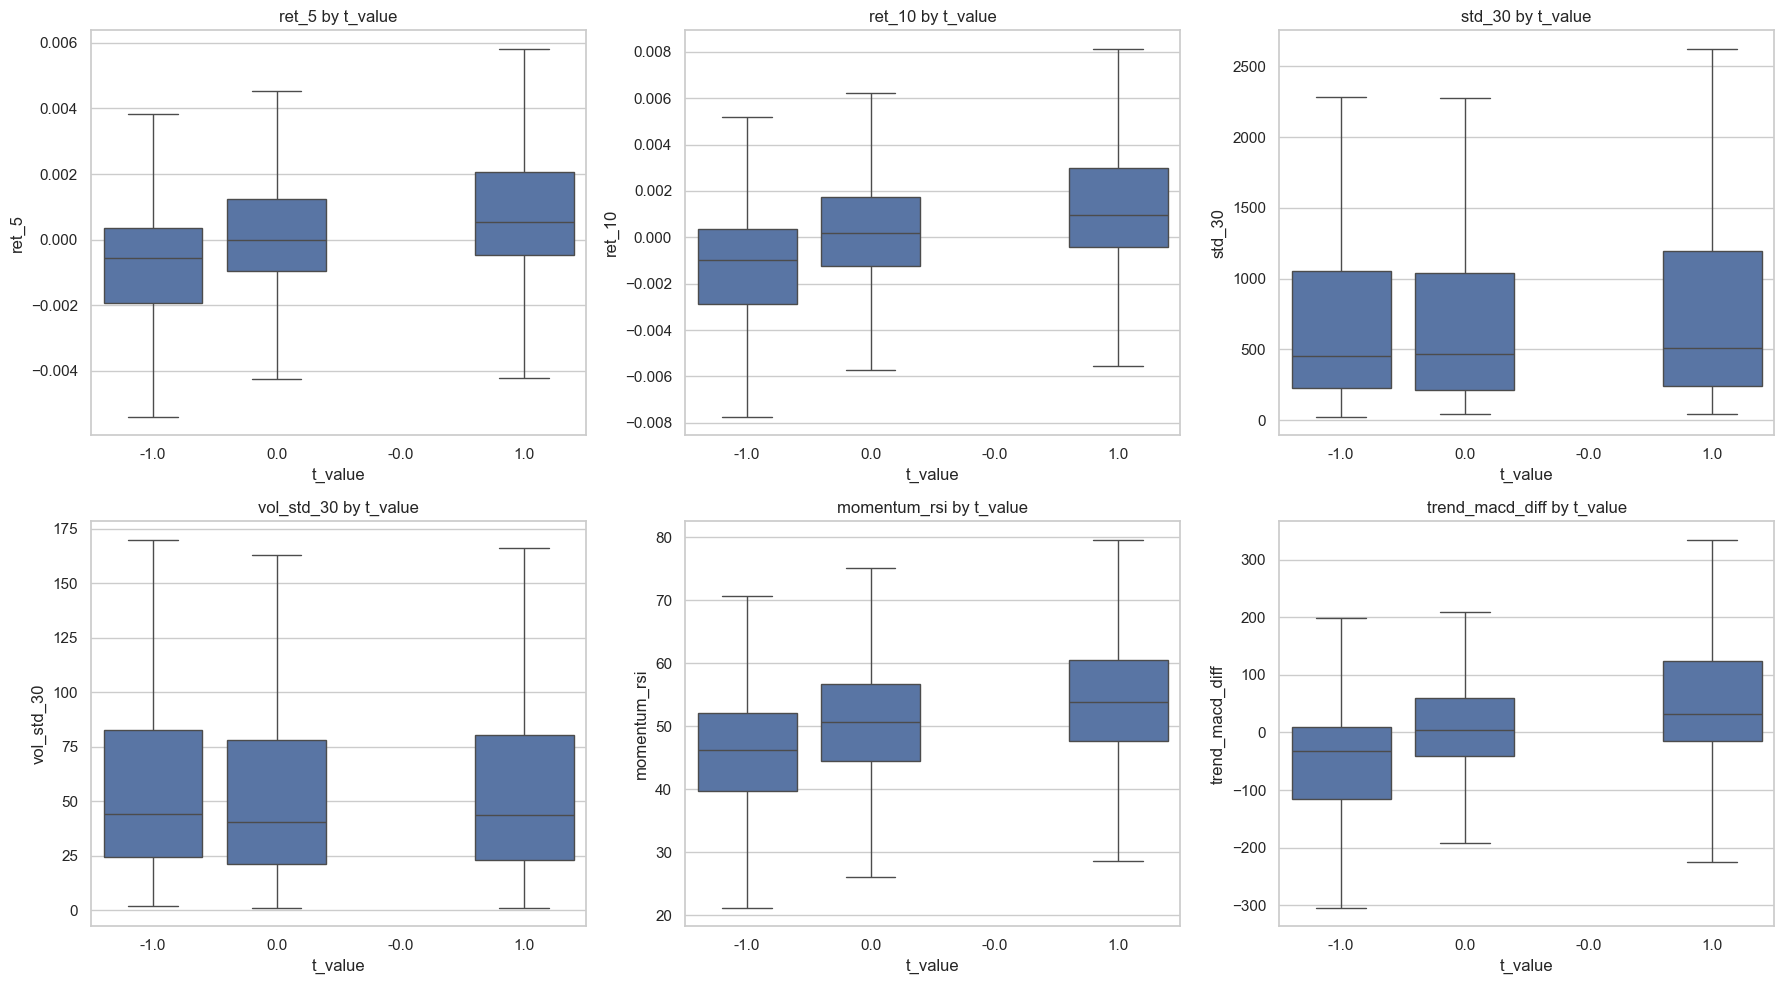

In [12]:
# 분류력 후보를 빠르게 보기 위해 대표 피처 몇 개만 선택한다.
sample_cols = [
    "ret_5",
    "ret_10",
    "std_30",
    "vol_std_30",
    "momentum_rsi",
    "trend_macd_diff",
]
available_cols = [col for col in sample_cols if col in feat.columns]

# boxplot은 클래스별 분포 차이를 직관적으로 보여준다.
# 전체 데이터를 그대로 그리면 너무 무거우므로 최대 2만건만 랜덤 샘플링한다.
plot_sample = feat[available_cols + ["t_value"]].dropna().copy()
if len(plot_sample) > 20000:
    plot_sample = plot_sample.sample(20000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# showfliers=False는 극단값 점을 숨겨 중앙 분포 차이를 읽기 쉽게 만든다.
for ax, col in zip(axes, available_cols):
    sns.boxplot(data=plot_sample, x="t_value", y=col, ax=ax, showfliers=False)
    ax.set_title(f"{col} by t_value")

# 피처 수가 6개보다 적은 경우 남는 축은 비워둔다.
for ax in axes[len(available_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 결과 해석
- `ret_5`, `ret_10`, `momentum_rsi`, `trend_macd_diff`는 `t_value = -1, 0, 1`에 따라 평균 방향이 비교적 깔끔하게 갈립니다. 예를 들어 `momentum_rsi` 평균은 약 **45.8 / 49.9 / 54.1**, `trend_macd_diff` 평균은 약 **-104 / -3 / 110**으로 차이가 분명합니다.
- 문제는 `std_30`, `vol_std_30`처럼 클래스 간 겹침이 큰 피처도 있다는 점입니다. 원인은 `t_value`가 방향성 라벨일 가능성이 높아 변동성 피처가 직접 분리되지 않기 때문이며, 해결방안은 `feature selection`, `비지도 이상탐지와 병행 비교`, `방향성/변동성 목표 분리`입니다. 인사이트는 기존 피처셋이 방향성 분류에는 유용할 수 있지만, 이상탐지 목적에는 추가 설계가 필요하다는 점입니다.


## 3. Next Step

1. `event_candidates.csv`에서 대표 이벤트 10~20개를 선정합니다.
2. `t_value` 생성 로직을 확인해 라벨 재사용 여부를 결정합니다.
3. `02_eda_feature_review.ipynb`에서 feature drift, 상관구조, label separability를 봅니다.
4. 첫 베이스라인은 `rolling z-score`, `EWMA`, `Isolation Forest` 순서로 진행합니다.
